In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
BASE_DIR = "/content/drive/MyDrive/AquaGpt"   # create this folder in Drive
os.makedirs(BASE_DIR, exist_ok=True)
os.chdir(BASE_DIR)
print("Working dir:", os.getcwd())


Working dir: /content/drive/MyDrive/AquaGpt


In [ ]:
import os, pandas as pd

os.chdir("/content/drive/MyDrive/AquaGpt")
print("Current dir:", os.getcwd())

df = pd.read_csv("groundwater-level-collected-telemetric.csv")
print("✅ Loaded successfully:", df.shape)
df.head()

Current dir: /content/drive/MyDrive/AquaGpt
✅ Loaded successfully: (50422, 22)


,id,station_name,station_code,station_type,station_status,data_acquisition_mode,agency_name,agency_id,well_type,well_aquifer_type,...,date_of_establishment,data_available_from,discharge_data_available,discharge,well_depth,date,time,data_type_code,data_type_description,data_value
0,0,Lakshmipur Pz,CGWHYD0191,Ground Water,Active,Telemetric,CGWB,113.0,Bore Well,Unconfined,...,NaN,NaN,No,NaN,64.0,12-07-2024,12:00:00,GGZ,GPRS-Water Level,-10.89
1,1,Lakshmipur Pz,CGWHYD0191,Ground Water,Active,Telemetric,CGWB,113.0,Bore Well,Unconfined,...,NaN,NaN,No,NaN,64.0,12-07-2024,18:00:00,GGZ,GPRS-Water Level,-10.91
2,2,Lakshmipur Pz,CGWHYD0191,Ground Water,Active,Telemetric,CGWB,113.0,Bore Well,Unconfined,...,NaN,NaN,No,NaN,64.0,13-07-2024,00:00:00,GGZ,GPRS-Water Level,-10.81
3,3,Lakshmipur Pz,CGWHYD0191,Ground Water,Active,Telemetric,CGWB,113.0,Bore Well,Unconfined,...,NaN,NaN,No,NaN,64.0,13-07-2024,06:00:00,GGZ,GPRS-Water Level,-10.79
4,4,Lakshmipur Pz,CGWHYD0191,Ground Water,Active,Telemetric,CGWB,113.0,Bore Well,Unconfined,...,NaN,NaN,No,NaN,64.0,13-07-2024,12:00:00,GGZ,GPRS-Water Level,-10.79


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = df.copy()

# Drop irrelevant/empty columns if present
for col in ['id', 'date_of_establishment', 'data_available_from']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Combine date + time into datetime (if present)
if {'date','time'}.issubset(df.columns):
    df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str), errors='coerce')
    df = df.drop(columns=['date','time'])
elif 'datetime' not in df.columns:
    df['datetime'] = pd.NaT

# Ensure target exists
if 'data_value' not in df.columns:
    raise ValueError("Expected 'data_value' column as target.")

# Drop rows without target
df = df.dropna(subset=['data_value']).copy()

# Fill numeric gaps
for col in ['discharge', 'well_depth']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical gaps with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Optional: time features (useful for ML, not the raw datetime)
if 'datetime' in df.columns:
    df['year']  = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day']   = df['datetime'].dt.day
    df['hour']  = df['datetime'].dt.hour

# Label-encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Normalize selected numeric columns to [0,1]
numeric_cols = [c for c in ['latitude','longitude','discharge','well_depth','data_value'] if c in df.columns]
scaler = MinMaxScaler()
if numeric_cols:
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Save normalized dataset for reuse
NORMALIZED_CSV = "normalized_groundwater_data.csv"
df.to_csv(NORMALIZED_CSV, index=False)
print(f"✅ Saved normalized data → {NORMALIZED_CSV}")
df.head()

✅ Saved normalized data → normalized_groundwater_data.csv


,station_name,station_code,station_type,station_status,data_acquisition_mode,agency_name,agency_id,well_type,well_aquifer_type,latitude,...,discharge,well_depth,data_type_code,data_type_description,data_value,datetime,year,month,day,hour
0,10,0,0,0,0,0,113.0,0,1,0.549719,...,0.259036,0.175758,0,0,0.213744,2024-12-07 12:00:00,2024.0,12.0,7.0,12.0
1,10,0,0,0,0,0,113.0,0,1,0.549719,...,0.259036,0.175758,0,0,0.213298,2024-12-07 18:00:00,2024.0,12.0,7.0,18.0
2,10,0,0,0,0,0,113.0,0,1,0.549719,...,0.259036,0.175758,0,0,0.215529,NaT,NaN,NaN,NaN,NaN
3,10,0,0,0,0,0,113.0,0,1,0.549719,...,0.259036,0.175758,0,0,0.215975,NaT,NaN,NaN,NaN,NaN
4,10,0,0,0,0,0,113.0,0,1,0.549719,...,0.259036,0.175758,0,0,0.215975,NaT,NaN,NaN,NaN,NaN


In [ ]:
from sklearn.model_selection import train_test_split

# Keep engineered date parts; drop raw datetime from features
X = df.drop(columns=[c for c in ['data_value','datetime'] if c in df.columns]).copy()
y = df['data_value'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train.shape, X_test.shape

((40336, 20), (10085, 20))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.4f}")

# Save metrics
OUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "model_metrics.txt"), "w", encoding="utf-8") as f:
    f.write(f"Mean Squared Error: {mse:.6f}\nR2 Score: {r2:.4f}\n")

print("✅ Metrics saved to output/model_metrics.txt")

Mean Squared Error: 0.001296
R² Score: 0.7948
✅ Metrics saved to output/model_metrics.txt


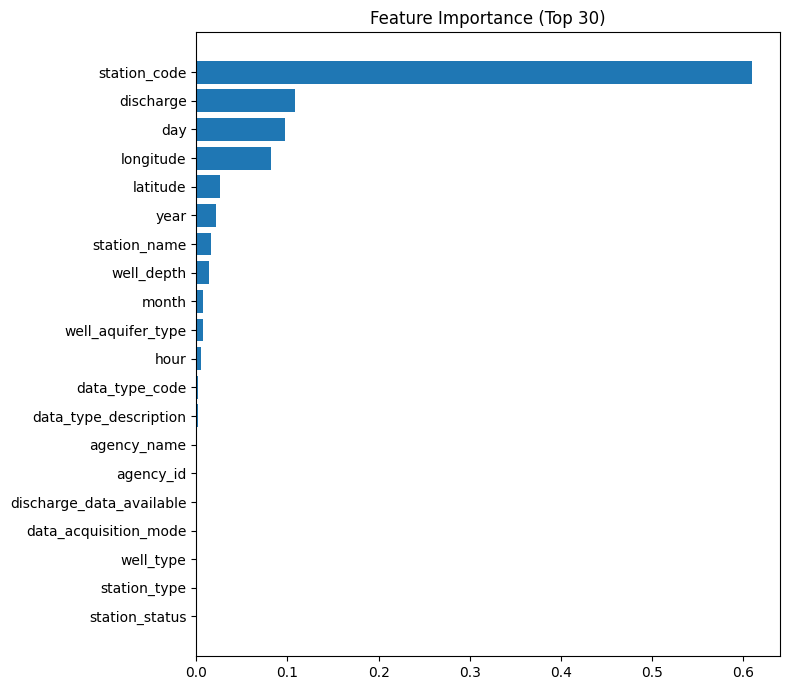

✅ Saved plot → /content/drive/MyDrive/AquaGpt/output/feature_importance.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

importances = model.feature_importances_
feat_names = np.array(X.columns)
order = np.argsort(importances)[::-1][:30]  # top 30

plt.figure(figsize=(8, max(4, len(order)*0.35)))
plt.barh(range(len(order)), importances[order])
plt.yticks(range(len(order)), feat_names[order])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Top 30)")
plt.tight_layout()

fi_path = os.path.join(OUT_DIR, "feature_importance.png")
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved plot → {fi_path}")

In [ ]:
import joblib

SAVE_DIR = os.path.join(BASE_DIR, "saved_model")
os.makedirs(SAVE_DIR, exist_ok=True)
model_path = os.path.join(SAVE_DIR, "groundwater_model.pkl")
joblib.dump(model, model_path)
print(f"✅ Model saved → {model_path}")

✅ Model saved → /content/drive/MyDrive/AquaGpt/saved_model/groundwater_model.pkl


In [ ]:
import joblib
import pandas as pd

# Load model from Drive
model_path = "/content/drive/MyDrive/AquaGpt/saved_model/groundwater_model.pkl"
model = joblib.load(model_path)

# Load normalized data or create new test data
df = pd.read_csv("/content/drive/MyDrive/AquaGpt/normalized_groundwater_data.csv")

# Use same feature columns that were used in training
X = df.drop(columns=[c for c in ['data_value', 'datetime'] if c in df.columns])

# Make predictions
predictions = model.predict(X.head(10))   # predict first 10 rows
print("Predictions:", predictions)

Predictions: [0.24033802 0.24045515 0.29074567 0.29074567 0.29074567 0.29074567
 0.29074567 0.29074567 0.29074567 0.29074567]


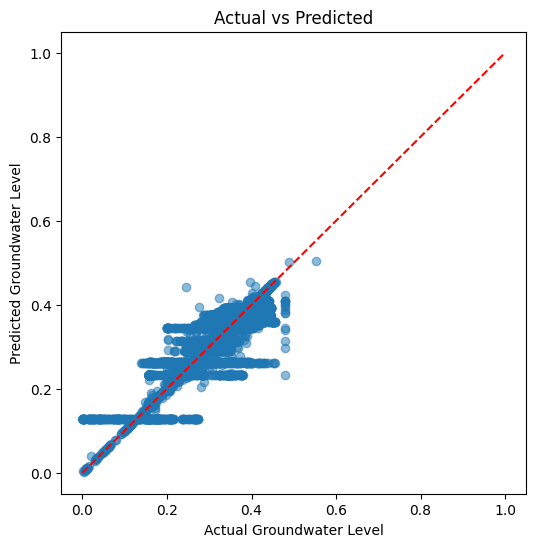

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already have y_test and y_pred from before
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Groundwater Level")
plt.ylabel("Predicted Groundwater Level")
plt.title("Actual vs Predicted")
plt.plot([0,1], [0,1], '--', color='red')  # perfect line
plt.show()

In [ ]:
with open('/content/drive/MyDrive/AquaGpt/output/model_metrics.txt') as f:
  print(f.read())

Mean Squared Error: 0.001296
R2 Score: 0.7948



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 0.001296
R² Score: 0.7948


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rand_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,   # only 10 random combos
    cv=2,        # 2-fold cross-validation
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# (Optional) use a small subset for tuning
X_tune = X_train.sample(frac=0.1, random_state=42)
y_tune = y_train.loc[X_tune.index]

rand_search.fit(X_tune, y_tune)
print("Best params:", rand_search.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}


In [ ]:
best_params = rand_search.best_params_
final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_final = final_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_final)
r2  = r2_score(y_test, y_pred_final)
print(f"Final MSE: {mse:.6f}")
print(f"Final R² : {r2:.4f}")

Final MSE: 0.001296
Final R² : 0.7948


In [ ]:
import os, json, joblib

BASE_DIR = "/content/drive/MyDrive/AquaGpt"
SAVE_DIR = os.path.join(BASE_DIR, "saved_model")
OUT_DIR  = os.path.join(BASE_DIR, "output")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Save model
final_model_path = os.path.join(SAVE_DIR, "groundwater_model_tuned.pkl")
joblib.dump(final_model, final_model_path)

# Save best params + feature order (very important for future predictions)
meta = {
    "best_params": best_params,
    "feature_order": list(X_train.columns)
}
with open(os.path.join(SAVE_DIR, "model_metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)

# Save metrics
with open(os.path.join(OUT_DIR, "final_metrics.txt"), "w") as f:
    f.write(f"Final MSE: {mse:.6f}\nFinal R2: {r2:.4f}\n")

print("✅ Saved:", final_model_path)
print("✅ Saved:", os.path.join(SAVE_DIR, "model_metadata.json"))
print("✅ Saved:", os.path.join(OUT_DIR, "final_metrics.txt"))

✅ Saved: /content/drive/MyDrive/AquaGpt/saved_model/groundwater_model_tuned.pkl
✅ Saved: /content/drive/MyDrive/AquaGpt/saved_model/model_metadata.json
✅ Saved: /content/drive/MyDrive/AquaGpt/output/final_metrics.txt


In [ ]:
import pandas as pd
import numpy as np

# Precompute fillers from your training data
num_fill = X_train.median(numeric_only=True).to_dict()
cat_fill = X_train.mode(dropna=True).iloc[0].to_dict()
fillers = {**cat_fill, **num_fill}

def predict_by_lat_lon(lat, lon, day=15, month=11, year=2024, hour=12):
    # Build one-row input with all required columns
    row = {col: fillers.get(col, 0) for col in X_train.columns}
    # overwrite key fields you want to supply
    if 'latitude'  in row: row['latitude']  = lat
    if 'longitude' in row: row['longitude'] = lon
    if 'day'       in row: row['day'] = day
    if 'month'     in row: row['month'] = month
    if 'year'      in row: row['year'] = year
    if 'hour'      in row: row['hour'] = hour

    df_one = pd.DataFrame([row], columns=X_train.columns)
    return float(final_model.predict(df_one)[0])

# Example:
print("Pred (normalized):", predict_by_lat_lon(lat=17.25, lon=78.45))

Pred (normalized): 0.412439387178344


In [ ]:
# Fit scaler on the ORIGINAL raw data, not the normalized one
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

raw_df = pd.read_csv("/content/drive/MyDrive/AquaGpt/groundwater-level-collected-telemetric.csv")

# Clean minimal columns (drop empty ones)
raw_df = raw_df.drop(columns=['id','date_of_establishment','data_available_from'], errors='ignore')

# Keep only numeric fields used for normalization earlier
scaler = MinMaxScaler()
scaler.fit(raw_df[['latitude','longitude','discharge','well_depth','data_value']])

/tmp/ipython-input-4084143462.py:5: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("/content/drive/MyDrive/AquaGpt/groundwater-level-collected-telemetric.csv")


MinMaxScaler()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Recreate scaler and fit it on the same columns from your training data
scaler = MinMaxScaler()
df_train = pd.read_csv("/content/drive/MyDrive/AquaGpt/normalized_groundwater_data.csv")
scaler.fit(df_train[['latitude','longitude','discharge','well_depth','data_value']])

# Your normalized output
pred_normalized = 0.41

# Convert it back to the original value
# Fill placeholders for the other 4 columns (values don’t matter here)
original_val = scaler.inverse_transform([[0,0,0,0,pred_normalized]])[0, -1]
print(f"Predicted groundwater level (original scale): {original_val:.2f}")

Predicted groundwater level (original scale): 0.41


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Paths
base_dir = "/content/drive/MyDrive/AquaGpt"
model_path = f"{base_dir}/saved_model/groundwater_model_tuned.pkl"
data_path = f"{base_dir}/normalized_groundwater_data.csv"

# Load the model
model = joblib.load(model_path)

# Refit the scaler on your full normalized dataset
df_train = pd.read_csv(data_path)
scaler = MinMaxScaler()
scaler.fit(df_train[['latitude','longitude','discharge','well_depth','data_value']])

MinMaxScaler()

In [ ]:
import numpy as np

def predict_groundwater_level_original(lat, lon, discharge=0.5, well_depth=0.5, day=15, month=11, year=2024, hour=12):
    """
    Predict groundwater level (original scale) for given latitude & longitude.
    """

    # Prepare default feature values using medians/modes
    num_fill = df_train.median(numeric_only=True).to_dict()
    cat_fill = df_train.mode(dropna=True).iloc[0].to_dict()
    fillers = {**cat_fill, **num_fill}

    # Create one-row DataFrame for input
    row = {col: fillers.get(col, 0) for col in df_train.columns if col not in ['data_value','datetime']}
    if 'latitude' in row: row['latitude'] = lat
    if 'longitude' in row: row['longitude'] = lon
    if 'discharge' in row: row['discharge'] = discharge
    if 'well_depth' in row: row['well_depth'] = well_depth
    if 'day' in row: row['day'] = day
    if 'month' in row: row['month'] = month
    if 'year' in row: row['year'] = year
    if 'hour' in row: row['hour'] = hour

    # Convert to DataFrame
    X_input = pd.DataFrame([row])

    # Predict normalized groundwater level
    pred_normalized = model.predict(X_input)[0]

    # Inverse transform to get original value
    original_val = scaler.inverse_transform([[0, 0, 0, 0, pred_normalized]])[0, -1]

    return round(float(original_val), 2)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load your ORIGINAL (unscaled) dataset
raw_df = pd.read_csv("/content/drive/MyDrive/AquaGpt/groundwater-level-collected-telemetric.csv")

# Drop missing data_value rows
raw_df = raw_df.dropna(subset=['data_value'])

# --- Fit scaler only on the target column ---
target_scaler = MinMaxScaler()
target_scaler.fit(raw_df[['data_value']])

def predict_groundwater_level_original(lat, lon, discharge=0.5, well_depth=0.5, day=15, month=11, year=2024, hour=12):
    """
    Predict groundwater level (original scale) for given latitude & longitude.
    """
    # Fillers for other features
    num_fill = df_train.median(numeric_only=True).to_dict()
    cat_fill = df_train.mode(dropna=True).iloc[0].to_dict()
    fillers = {**cat_fill, **num_fill}

    row = {col: fillers.get(col, 0) for col in df_train.columns if col not in ['data_value','datetime']}
    if 'latitude' in row: row['latitude'] = lat
    if 'longitude' in row: row['longitude'] = lon
    if 'discharge' in row: row['discharge'] = discharge
    if 'well_depth' in row: row['well_depth'] = well_depth
    if 'day' in row: row['day'] = day
    if 'month' in row: row['month'] = month
    if 'year' in row: row['year'] = year
    if 'hour' in row: row['hour'] = hour

    X_input = pd.DataFrame([row])
    pred_normalized = model.predict(X_input)[0]

    # --- Inverse transform using only data_value scaler ---
    original_val = target_scaler.inverse_transform(np.array([[pred_normalized]]))[0, 0]
    return round(float(original_val), 2)

/tmp/ipython-input-3377523700.py:6: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("/content/drive/MyDrive/AquaGpt/groundwater-level-collected-telemetric.csv")


In [ ]:
print("🌊 Predicted Groundwater Level (original scale):",
      predict_groundwater_level_original(17.25, 78.45),
      "meters")

🌊 Predicted Groundwater Level (original scale): 1099.69 meters
